In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import numpy as np
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [3]:
X_train_kde = np.load('./X_train_kde.npy')
y_train_kde = np.load('./y_train_fixed.npy')
X_test_kde = np.load('./X_test_kde.npy')
y_test_kde = np.load('./y_test_fixed.npy')
scaler = StandardScaler()
scaler.fit(X_train_kde)
X_train_kde = scaler.transform(X_train_kde)
X_test_kde = scaler.transform(X_test_kde)

In [14]:
# hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(8, 30),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=15,
    cv=5,
    random_state=42,
)

search.fit(X_train_kde, y_train_kde)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=15,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7837a8c53530>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7837a8b32390>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7837a8b33aa0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7837a8e11160>},
                   random_state=42)

Accuracy: 0.382


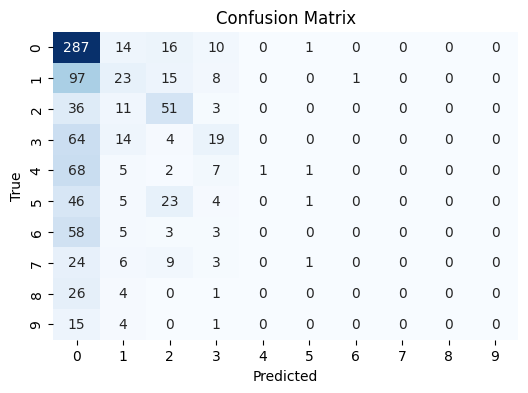

In [15]:
#evaluate
best_rf = search.best_estimator_
best_rf.fit(X_train_kde, y_train_kde)
y_pred = best_rf.predict(X_test_kde)

accuracy = accuracy_score(y_test_kde, y_pred)
print(f'Accuracy: {accuracy}')

conf_matrix = confusion_matrix(y_test_kde, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [16]:
per_class_accuracy = np.diag(conf_matrix) / conf_matrix.sum(axis=1)

In [17]:
per_class_accuracy

array([0.875     , 0.15972222, 0.5049505 , 0.18811881, 0.01190476,
       0.01265823, 0.        , 0.        , 0.        , 0.        ])

### K Means Features

In [8]:
X_train_kms = np.load('./X_train_kms.npy')
y_train_kms = np.load('./y_train_fixed.npy')
X_test_kms = np.load('./X_test_kms.npy')
y_test_kms = np.load('./y_test_fixed.npy')
scaler = StandardScaler()
scaler.fit(X_train_kms)
X_train_kms = scaler.transform(X_train_kms)
X_test_kms = scaler.transform(X_test_kms)

In [23]:
# hyperparameter tuning

param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(8, 30),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
}

kms_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=15,
    cv=5,
    random_state=42,
)

In [24]:
kms_search.fit(X_train_kms, y_train_kms)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=15,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7837a8b31ca0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7837a88e9b20>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7837a8dd2ff0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7837a88ead80>},
                   random_state=42)

Accuracy: 0.371


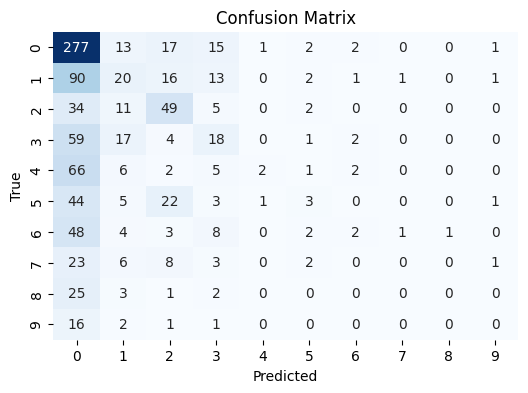

In [25]:
#evaluate k means
best_rf_kms = kms_search.best_estimator_
best_rf_kms.fit(X_train_kms, y_train_kms)
y_pred = best_rf_kms.predict(X_test_kms)

accuracy = accuracy_score(y_test_kms, y_pred)
print(f'Accuracy: {accuracy}')

conf_matrix = confusion_matrix(y_test_kms, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [26]:
per_class_accuracy = np.diag(conf_matrix) / conf_matrix.sum(axis=1)
per_class_accuracy

array([0.8445122 , 0.13888889, 0.48514851, 0.17821782, 0.02380952,
       0.03797468, 0.02898551, 0.        , 0.        , 0.        ])